# 2. Baseline Model — Ridge Regression

## Why Ridge as the baseline?
The EDA (§11 of `1_eda.ipynb`) showed four signals a model must capture: weekly seasonality, holiday dips, weekday × intra-day profile, and (non-linear) staffing interaction. Ridge can handle the first three cleanly with explicit calendar features + polynomial interactions — it's fast, fully interpretable, and gives us an honest floor on achievable error before we reach for anything more complex.

It **cannot** capture non-linear staffing interactions or heavy-tailed residuals well. That's intentional: we want the baseline to fail in a *diagnosable* way so the validation notebook can tell us what kind of model complexity is actually justified.

## Architecture
- **Stage 1 (daily):** Ridge regression on daily data with rich feature engineering (DOW, month, holidays, lags, rolling stats, staffing, polynomial interactions)
- **Stage 2 (interval):** Learn DOW × half-hour disaggregation profiles from historical 30-min data, then multiply daily predictions by the proportions to produce interval forecasts



In [9]:
import pandas as pd
import numpy as np
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import RidgeCV
from sklearn.metrics import mean_absolute_error
from datetime import datetime, timedelta
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

DATA_FILE = "Data for Datathon (Revised).xlsx"
TEMPLATE_FILE = "template_forecast_v00.csv"
PORTFOLIOS = ['A', 'B', 'C', 'D']
MONTH_MAP = {'January': 1, 'February': 2, 'March': 3, 'April': 4,
             'May': 5, 'June': 6, 'July': 7, 'August': 8,
             'September': 9, 'October': 10, 'November': 11, 'December': 12}

US_HOLIDAYS = set([
    datetime(2024, 1, 1), datetime(2024, 1, 15), datetime(2024, 2, 19),
    datetime(2024, 5, 27), datetime(2024, 7, 4), datetime(2024, 9, 2),
    datetime(2024, 10, 14), datetime(2024, 11, 11), datetime(2024, 11, 28),
    datetime(2024, 12, 25),
    datetime(2025, 1, 1), datetime(2025, 1, 20), datetime(2025, 2, 17),
    datetime(2025, 5, 26), datetime(2025, 7, 4), datetime(2025, 9, 1),
    datetime(2025, 10, 13), datetime(2025, 11, 11), datetime(2025, 11, 27),
    datetime(2025, 12, 25)
])

DAILY_METRICS = ['Call Volume', 'CCT', 'Abandon Rate']

## 1. Load Data

In [10]:
# Load daily data
daily_data = {}
for p in PORTFOLIOS:
    df = pd.read_excel(DATA_FILE, sheet_name=f"{p} - Daily")
    df['Date'] = pd.to_datetime(df['Date'].str.strip().str[:8], format='%m/%d/%y')
    df = df.sort_values('Date').reset_index(drop=True)
    # Temporal features
    df['dow'] = df['Date'].dt.dayofweek
    df['month'] = df['Date'].dt.month
    df['day_of_month'] = df['Date'].dt.day
    df['week_of_year'] = df['Date'].dt.isocalendar().week.astype(int)
    df['is_weekend'] = (df['dow'] >= 5).astype(int)
    df['is_holiday'] = df['Date'].isin(US_HOLIDAYS).astype(int)
    df['year'] = df['Date'].dt.year
    df['day_of_year'] = df['Date'].dt.dayofyear
    df['is_month_start'] = (df['day_of_month'] <= 3).astype(int)
    df['is_month_end'] = (df['day_of_month'] >= 28).astype(int)
    df['is_friday'] = (df['dow'] == 4).astype(int)
    df['is_monday'] = (df['dow'] == 0).astype(int)
    df['is_day_after_holiday'] = df['Date'].apply(
        lambda d: int((d - timedelta(days=1)) in US_HOLIDAYS))
    daily_data[p] = df

# Load interval data
interval_data = {}
for p in PORTFOLIOS:
    df = pd.read_excel(DATA_FILE, sheet_name=f"{p} - Interval")
    df = df.dropna(subset=['Interval', 'Call Volume']).reset_index(drop=True)
    df['Interval'] = df['Interval'].astype(str)
    def parse_interval(val):
        val = str(val).strip()
        if 'days' in val:
            return val.split(' ')[-1][:5]
        return val[:5] if len(val) >= 5 else val
    df['Interval_str'] = df['Interval'].apply(parse_interval)
    df['half_hour'] = df['Interval_str'].apply(
        lambda x: int(x.split(':')[0]) * 2 + (1 if int(x.split(':')[1]) >= 30 else 0))
    df['month_num'] = df['Month'].map(MONTH_MAP)
    dates = []
    for _, row in df.iterrows():
        try:
            dates.append(datetime(2025, row['month_num'], row['Day']))
        except ValueError:
            dates.append(None)
    df['Date'] = pd.to_datetime(dates)
    df = df.dropna(subset=['Date']).reset_index(drop=True)
    df['dow'] = df['Date'].dt.dayofweek
    interval_data[p] = df

# Load staffing
staffing = pd.read_excel(DATA_FILE, sheet_name="Daily Staffing")
staffing.rename(columns={'Unnamed: 0': 'Date'}, inplace=True)
staffing['Date'] = pd.to_datetime(staffing['Date'])

print("Loaded.")
for p in PORTFOLIOS:
    print(f"  {p}: {len(daily_data[p])} daily ({daily_data[p]['Date'].min().date()} to {daily_data[p]['Date'].max().date()}), {len(interval_data[p])} interval")

Loaded.
  A: 731 daily (2024-01-01 to 2025-12-31), 3995 interval
  B: 731 daily (2024-01-01 to 2025-12-31), 4185 interval
  C: 731 daily (2024-01-01 to 2025-12-31), 4290 interval
  D: 731 daily (2024-01-01 to 2025-12-31), 4285 interval


## 2. Stage 1: Feature Engineering

Ridge regression needs explicit feature encoding since it cannot learn non-linear interactions.
We use one-hot encoding for categorical features, Fourier terms for yearly seasonality, and
lag/rolling features for temporal dependencies.

In [11]:
def build_daily_features(df, staffing_df, portfolio_label, portfolio_id):
    """Build feature-rich daily dataframe for Ridge regression."""
    d = df.copy()
    d['portfolio'] = portfolio_id
    
    # Fourier features for yearly seasonality
    d['sin_doy_1'] = np.sin(2 * np.pi * d['day_of_year'] / 365)
    d['cos_doy_1'] = np.cos(2 * np.pi * d['day_of_year'] / 365)
    d['sin_doy_2'] = np.sin(4 * np.pi * d['day_of_year'] / 365)
    d['cos_doy_2'] = np.cos(4 * np.pi * d['day_of_year'] / 365)
    
    # Lag features per metric
    for metric in DAILY_METRICS:
        for lag in [1, 7, 14, 28, 365]:
            d[f'{metric}_lag{lag}'] = d[metric].shift(lag)
        # Rolling features
        for window in [7, 14, 28]:
            d[f'{metric}_roll{window}'] = d[metric].rolling(window).mean().shift(1)
        # Rolling std (7-day)
        d[f'{metric}_rollstd7'] = d[metric].rolling(7).std().shift(1)
        # Same DOW average (last 2 weeks)
        d[f'{metric}_same_dow_avg'] = (d[metric].shift(7) + d[metric].shift(14)) / 2
    
    # Merge staffing
    staff = staffing_df[['Date', portfolio_label]].copy()
    staff.columns = ['Date', 'staffing']
    d = d.merge(staff, on='Date', how='left')
    
    return d


# Build combined daily dataset for all portfolios
all_daily = []
for i, p in enumerate(PORTFOLIOS):
    feat = build_daily_features(daily_data[p], staffing, p, i)
    all_daily.append(feat)

daily_df = pd.concat(all_daily, ignore_index=True)
print(f"Daily training data: {daily_df.shape}")
print(f"Date range: {daily_df['Date'].min().date()} to {daily_df['Date'].max().date()}")


def apply_onehot(df, fit_df=None):
    """
    Apply one-hot encoding for DOW, month, portfolio.
    If fit_df is provided, use its columns for alignment (for prediction).
    Returns the one-hot encoded dataframe.
    """
    out = df.copy()
    # One-hot encode DOW (7 -> 6 with drop_first)
    dow_dummies = pd.get_dummies(out['dow'], prefix='dow', drop_first=True).astype(float)
    # One-hot encode month (12 -> 11)
    month_dummies = pd.get_dummies(out['month'], prefix='month', drop_first=True).astype(float)
    # One-hot encode portfolio (4 -> 3)
    port_dummies = pd.get_dummies(out['portfolio'], prefix='portfolio', drop_first=True).astype(float)
    
    out = pd.concat([out, dow_dummies, month_dummies, port_dummies], axis=1)
    # Drop original categorical columns
    out = out.drop(columns=['dow', 'month', 'portfolio'], errors='ignore')
    
    return out


# Define feature sets
# Base numeric features (these will be present after one-hot encoding)
BASE_NUMERIC = [
    'is_weekend', 'is_holiday', 'is_monday', 'is_friday',
    'is_month_start', 'is_month_end', 'is_day_after_holiday',
    'day_of_year', 'week_of_year', 'year',
    'sin_doy_1', 'cos_doy_1', 'sin_doy_2', 'cos_doy_2',
]

# Lag/rolling features per metric
CV_LAG_FEATURES = [
    'Call Volume_lag1', 'Call Volume_lag7', 'Call Volume_lag14', 'Call Volume_lag28', 'Call Volume_lag365',
    'Call Volume_roll7', 'Call Volume_roll14', 'Call Volume_roll28',
    'Call Volume_rollstd7',
    'Call Volume_same_dow_avg',
    'staffing',
]

CCT_LAG_FEATURES = [
    'CCT_lag7', 'CCT_lag14', 'CCT_lag28', 'CCT_lag365',
    'CCT_roll7', 'CCT_roll14', 'CCT_roll28',
    'CCT_rollstd7',
    'CCT_same_dow_avg',
    'staffing',
]

ABD_LAG_FEATURES = [
    'Abandon Rate_lag7', 'Abandon Rate_lag14', 'Abandon Rate_lag28', 'Abandon Rate_lag365',
    'Abandon Rate_roll7', 'Abandon Rate_roll14', 'Abandon Rate_roll28',
    'Abandon Rate_rollstd7',
    'Abandon Rate_same_dow_avg',
    'Call Volume_lag7',  # volume pressure drives abandon rate
    'staffing',
]

DAILY_TARGETS = {'cv': 'Call Volume', 'cct': 'CCT', 'abd': 'Abandon Rate'}
METRIC_LAG_FEATURES = {'cv': CV_LAG_FEATURES, 'cct': CCT_LAG_FEATURES, 'abd': ABD_LAG_FEATURES}

print("Feature engineering complete.")
print(f"Base numeric features: {len(BASE_NUMERIC)}")
print(f"One-hot columns will add: 6 (DOW) + 11 (month) + 3 (portfolio) = 20")

Daily training data: (2924, 54)
Date range: 2024-01-01 to 2025-12-31
Feature engineering complete.
Base numeric features: 14
One-hot columns will add: 6 (DOW) + 11 (month) + 3 (portfolio) = 20


## 3. Stage 1: Validation (July 2025)

Train Ridge models on data up to June 30, 2025; validate on July 2025.
Report MAE and WMAPE per portfolio per metric.

In [12]:
# Split: train through June 2025, validate on July 2025
train_mask = daily_df['Date'] < datetime(2025, 7, 1)
val_mask = daily_df['Date'] >= datetime(2025, 7, 1)

print(f"Train: {train_mask.sum()} rows (up to Jun 2025)")
print(f"Val: {val_mask.sum()} rows (Jul 2025+)")
print(f"Val date range: {daily_df[val_mask]['Date'].min().date()} to {daily_df[val_mask]['Date'].max().date()}")

# Apply one-hot encoding to full daily_df
daily_df_oh = apply_onehot(daily_df)

# Get all one-hot column names (DOW, month, portfolio dummies)
oh_cols = [c for c in daily_df_oh.columns if c.startswith('dow_') or c.startswith('month_') or c.startswith('portfolio_')]

# RidgeCV with built-in alpha search
alphas = np.logspace(-2, 4, 50)

val_models = {}
val_predictions = {}

print("\n" + "="*80)
for metric_key, target_col in DAILY_TARGETS.items():
    lag_feats = METRIC_LAG_FEATURES[metric_key]
    feature_cols = BASE_NUMERIC + oh_cols + lag_feats
    
    # Prepare train/val
    X_tr = daily_df_oh[train_mask][feature_cols].copy()
    y_tr = daily_df_oh[train_mask][target_col].copy()
    X_va = daily_df_oh[val_mask][feature_cols].copy()
    y_va = daily_df_oh[val_mask][target_col].copy()
    
    # Drop rows with NaN target or features
    valid_tr = y_tr.notna() & X_tr.notna().all(axis=1)
    valid_va = y_va.notna() & X_va.notna().all(axis=1)
    X_tr, y_tr = X_tr[valid_tr], y_tr[valid_tr]
    X_va, y_va = X_va[valid_va], y_va[valid_va]
    
    print(f"\n{metric_key.upper()} ({target_col}):")
    print(f"  Train: {len(X_tr)} rows, Val: {len(X_va)} rows, Features: {len(feature_cols)}")
    
    # Fit Pipeline: StandardScaler + RidgeCV
    model = Pipeline([
        ('scaler', StandardScaler()),
        ('ridge', RidgeCV(alphas=alphas, cv=5))
    ])
    model.fit(X_tr, y_tr)
    
    best_alpha = model.named_steps['ridge'].alpha_
    print(f"  Best alpha: {best_alpha:.4f}")
    
    # Predict on validation set
    val_pred = model.predict(X_va)
    
    # Clip predictions
    if metric_key == 'cv':
        val_pred = np.clip(val_pred, 0, None)
    elif metric_key == 'cct':
        val_pred = np.clip(val_pred, 0, None)
    elif metric_key == 'abd':
        val_pred = np.clip(val_pred, 0, 1)
    
    # Overall metrics
    mae = mean_absolute_error(y_va, val_pred)
    wmape = np.sum(np.abs(y_va.values - val_pred)) / np.sum(np.abs(y_va.values)) if np.sum(np.abs(y_va.values)) > 0 else 0
    bias = np.mean(val_pred - y_va.values)
    print(f"  Overall: MAE={mae:.2f}, WMAPE={wmape:.4f}, Bias={bias:+.2f}")
    
    # Per-portfolio metrics
    portfolio_ids = daily_df_oh[val_mask][valid_va]['portfolio'].values if 'portfolio' in daily_df_oh.columns else daily_df[val_mask][valid_va]['portfolio'].values
    # Recover portfolio from one-hot (reconstruct from original daily_df)
    port_series = daily_df[val_mask]['portfolio']
    port_vals = port_series[valid_va].values
    for pid, plabel in enumerate(PORTFOLIOS):
        pmask = port_vals == pid
        if pmask.sum() > 0:
            p_mae = mean_absolute_error(y_va.values[pmask], val_pred[pmask])
            p_actual_sum = np.sum(np.abs(y_va.values[pmask]))
            p_wmape = np.sum(np.abs(y_va.values[pmask] - val_pred[pmask])) / p_actual_sum if p_actual_sum > 0 else 0
            print(f"    {plabel}: MAE={p_mae:.2f}, WMAPE={p_wmape:.4f}")
    
    val_models[metric_key] = model
    val_predictions[metric_key] = val_pred

print("\n" + "="*80)
print("Validation complete.")

Train: 2188 rows (up to Jun 2025)
Val: 736 rows (Jul 2025+)
Val date range: 2025-07-01 to 2025-12-31


CV (Call Volume):
  Train: 602 rows, Val: 546 rows, Features: 45
  Best alpha: 20.2359
  Overall: MAE=936.91, WMAPE=0.0908, Bias=-496.52
    A: MAE=642.44, WMAPE=0.1710
    B: MAE=888.30, WMAPE=0.1031
    C: MAE=1394.29, WMAPE=0.0740
    D: MAE=795.60, WMAPE=0.0828

CCT (CCT):
  Train: 541 rows, Val: 555 rows, Features: 44
  Best alpha: 8.6851
  Overall: MAE=25.28, WMAPE=0.0760, Bias=-23.40
    A: MAE=23.93, WMAPE=0.0752
    B: MAE=31.82, WMAPE=0.0930
    C: MAE=23.67, WMAPE=0.0693
    D: MAE=22.25, WMAPE=0.0679

ABD (Abandon Rate):
  Train: 613 rows, Val: 554 rows, Features: 45
  Best alpha: 15.2642
  Overall: MAE=0.01, WMAPE=0.7760, Bias=+0.00
    A: MAE=0.01, WMAPE=0.6265
    B: MAE=0.01, WMAPE=0.6407
    C: MAE=0.01, WMAPE=0.9510
    D: MAE=0.01, WMAPE=0.8627

Validation complete.


## 4. Stage 1: Retrain & Predict August

Retrain on ALL daily data (including July), then predict August 1-31 daily values.

In [13]:
# Retrain on ALL daily data
final_models = {}
august_daily_preds = {p: {} for p in PORTFOLIOS}

for metric_key, target_col in DAILY_TARGETS.items():
    lag_feats = METRIC_LAG_FEATURES[metric_key]
    feature_cols = BASE_NUMERIC + oh_cols + lag_feats
    
    X_full = daily_df_oh[feature_cols].copy()
    y_full = daily_df_oh[target_col].copy()
    valid = y_full.notna() & X_full.notna().all(axis=1)
    X_full, y_full = X_full[valid], y_full[valid]
    
    model = Pipeline([
        ('scaler', StandardScaler()),
        ('ridge', RidgeCV(alphas=alphas, cv=5))
    ])
    model.fit(X_full, y_full)
    
    best_alpha = model.named_steps['ridge'].alpha_
    final_models[metric_key] = model
    print(f"{metric_key.upper()}: Retrained on {len(X_full)} rows, alpha={best_alpha:.4f}")


# Build August feature frames and predict
for pid, p in enumerate(PORTFOLIOS):
    d = daily_data[p].copy()
    aug_rows = []
    
    for day in range(1, 32):
        aug_date = datetime(2025, 8, day)
        row = {
            'Date': aug_date,
            'dow': aug_date.weekday(),
            'month': 8,
            'day_of_month': day,
            'week_of_year': aug_date.isocalendar()[1],
            'is_weekend': int(aug_date.weekday() >= 5),
            'is_holiday': int(aug_date in US_HOLIDAYS),
            'year': 2025,
            'day_of_year': aug_date.timetuple().tm_yday,
            'is_month_start': int(day <= 3),
            'is_month_end': int(day >= 28),
            'is_friday': int(aug_date.weekday() == 4),
            'is_monday': int(aug_date.weekday() == 0),
            'is_day_after_holiday': int((aug_date - timedelta(days=1)) in US_HOLIDAYS),
            'portfolio': pid,
            # Fourier features
            'sin_doy_1': np.sin(2 * np.pi * aug_date.timetuple().tm_yday / 365),
            'cos_doy_1': np.cos(2 * np.pi * aug_date.timetuple().tm_yday / 365),
            'sin_doy_2': np.sin(4 * np.pi * aug_date.timetuple().tm_yday / 365),
            'cos_doy_2': np.cos(4 * np.pi * aug_date.timetuple().tm_yday / 365),
        }
        
        # Lag features from historical daily data
        for metric in DAILY_METRICS:
            for lag in [1, 7, 14, 28, 365]:
                lag_date = aug_date - timedelta(days=lag)
                lag_row = d[d['Date'] == lag_date]
                row[f'{metric}_lag{lag}'] = lag_row[metric].values[0] if len(lag_row) > 0 else np.nan
            # Rolling features
            for window in [7, 14, 28]:
                end = aug_date - timedelta(days=1)
                start = end - timedelta(days=window - 1)
                w = d[(d['Date'] >= start) & (d['Date'] <= end)][metric]
                row[f'{metric}_roll{window}'] = w.mean() if len(w) > 0 else np.nan
            # Rolling std 7
            end = aug_date - timedelta(days=1)
            start = end - timedelta(days=6)
            w7 = d[(d['Date'] >= start) & (d['Date'] <= end)][metric]
            row[f'{metric}_rollstd7'] = w7.std() if len(w7) > 1 else np.nan
            # Same DOW avg
            l7 = row.get(f'{metric}_lag7', np.nan)
            l14 = row.get(f'{metric}_lag14', np.nan)
            vals = [v for v in [l7, l14] if not (isinstance(v, float) and np.isnan(v))]
            row[f'{metric}_same_dow_avg'] = np.mean(vals) if vals else np.nan
        
        # Staffing
        staff_row = staffing[staffing['Date'] == aug_date]
        if len(staff_row) > 0:
            row['staffing'] = staff_row[p].values[0]
        else:
            # Use same DOW from most recent available staffing
            same_dow = staffing[staffing['Date'].dt.weekday == aug_date.weekday()].sort_values('Date')
            row['staffing'] = same_dow[p].iloc[-1] if len(same_dow) > 0 else np.nan
        
        aug_rows.append(row)
    
    aug_daily = pd.DataFrame(aug_rows)
    
    # Apply one-hot encoding
    aug_oh = apply_onehot(aug_daily)
    
    # Align columns: ensure all one-hot columns exist (fill missing with 0)
    for col in oh_cols:
        if col not in aug_oh.columns:
            aug_oh[col] = 0.0
    
    # Predict each metric
    for metric_key, target_col in DAILY_TARGETS.items():
        lag_feats = METRIC_LAG_FEATURES[metric_key]
        feature_cols = BASE_NUMERIC + oh_cols + lag_feats
        
        X_aug = aug_oh[feature_cols].copy()
        # Fill NaN features with 0 for Ridge (imputation)
        X_aug = X_aug.fillna(0)
        
        pred = final_models[metric_key].predict(X_aug)
        
        # Clip
        if metric_key == 'cv':
            pred = np.clip(pred, 0, None)
        elif metric_key == 'cct':
            pred = np.clip(pred, 0, None)
        elif metric_key == 'abd':
            pred = np.clip(pred, 0, 1)
        
        august_daily_preds[p][target_col] = pred
    
    august_daily_preds[p]['Date'] = aug_daily['Date']
    august_daily_preds[p]['dow'] = aug_daily['dow']
    
    print(f"\nPortfolio {p} August daily:")
    print(f"  CV: mean={august_daily_preds[p]['Call Volume'].mean():.0f}, "
          f"min={august_daily_preds[p]['Call Volume'].min():.0f}, "
          f"max={august_daily_preds[p]['Call Volume'].max():.0f}")
    print(f"  CCT: mean={august_daily_preds[p]['CCT'].mean():.1f}")
    print(f"  ABD: mean={august_daily_preds[p]['Abandon Rate'].mean():.4f}")

CV: Retrained on 1148 rows, alpha=2.1210
CCT: Retrained on 1096 rows, alpha=26.8270
ABD: Retrained on 1167 rows, alpha=1389.4955

Portfolio A August daily:
  CV: mean=4133, min=1219, max=6454
  CCT: mean=326.4
  ABD: mean=0.0152

Portfolio B August daily:
  CV: mean=7961, min=3474, max=11339
  CCT: mean=329.7
  ABD: mean=0.0163

Portfolio C August daily:
  CV: mean=17865, min=8968, max=23018
  CCT: mean=331.4
  ABD: mean=0.0164

Portfolio D August daily:
  CV: mean=9062, min=4279, max=12343
  CCT: mean=329.5
  ABD: mean=0.0158


## 5. Stage 2: Disaggregation Profiles

Learn DOW x half_hour profiles from interval data:
- Call Volume: proportions normalized to sum=1.0 per DOW
- CCT: average by DOW x half_hour directly
- Abandon Rate: average by DOW x half_hour directly

In [14]:
cv_profiles = {}
cct_profiles = {}
abd_profiles = {}

for p in PORTFOLIOS:
    idf = interval_data[p].copy()
    
    # Only keep complete days (exactly 48 intervals)
    day_counts = idf.groupby('Date').size()
    complete_days = day_counts[day_counts == 48].index
    idf_complete = idf[idf['Date'].isin(complete_days)].copy()
    print(f'{p}: {len(complete_days)}/{len(day_counts)} complete days used for profiles')
    
    # If too few complete days, use all days with gap-filling
    if len(complete_days) < 14:
        print(f'  WARNING: Too few complete days, using all days with gap-filling')
        all_dates = idf['Date'].unique()
        full_grid = pd.MultiIndex.from_product([all_dates, range(48)], names=['Date', 'half_hour'])
        idf_complete = idf.set_index(['Date', 'half_hour']).reindex(full_grid).reset_index()
        idf_complete['Call Volume'] = idf_complete['Call Volume'].fillna(0)
        idf_complete['CCT'] = idf_complete['CCT'].fillna(idf['CCT'].mean())
        idf_complete['Abandoned Rate'] = idf_complete['Abandoned Rate'].fillna(0)
        idf_complete['dow'] = idf_complete['Date'].dt.dayofweek
    
    # Call Volume proportions
    daily_totals = idf_complete.groupby('Date')['Call Volume'].sum().reset_index()
    daily_totals.columns = ['Date', 'daily_total']
    idf_complete = idf_complete.merge(daily_totals, on='Date')
    idf_complete['cv_proportion'] = np.where(
        idf_complete['daily_total'] > 0,
        idf_complete['Call Volume'] / idf_complete['daily_total'],
        1.0 / 48
    )
    
    # Average proportion by DOW x half_hour, then normalize per DOW
    cv_raw = idf_complete.groupby(['dow', 'half_hour'])['cv_proportion'].mean()
    cv_normalized = {}
    for dow in range(7):
        dow_props = {hh: cv_raw.get((dow, hh), 1/48) for hh in range(48)}
        total = sum(dow_props.values())
        for hh in range(48):
            cv_normalized[(dow, hh)] = dow_props[hh] / total if total > 0 else 1/48
    cv_profiles[p] = cv_normalized
    
    # CCT: average by DOW x half_hour
    cct_vals = idf_complete[idf_complete['CCT'].notna()].groupby(['dow', 'half_hour'])['CCT'].mean().to_dict()
    cct_profiles[p] = cct_vals
    
    # Abandon Rate: average by DOW x half_hour
    abd_vals = idf_complete[idf_complete['Abandoned Rate'].notna()].groupby(['dow', 'half_hour'])['Abandoned Rate'].mean().to_dict()
    abd_profiles[p] = abd_vals
    
    # Verify normalization
    for dow in range(7):
        total = sum(cv_normalized.get((dow, hh), 0) for hh in range(48))
        if abs(total - 1.0) > 0.001:
            print(f'  ERROR: {p} DOW={dow} sums to {total:.6f}')

print('\nAll CV profiles normalized to sum=1.0 per DOW.')

A: 4/91 complete days used for profiles
B: 33/91 complete days used for profiles
C: 81/91 complete days used for profiles
D: 76/91 complete days used for profiles

All CV profiles normalized to sum=1.0 per DOW.


## 6. Combine & Output

Apply daily predictions x interval profiles to fill the template.

In [15]:
template = pd.read_csv(TEMPLATE_FILE)

def interval_to_halfhour(s):
    h, m = int(s.split(':')[0]), int(s.split(':')[1])
    return h * 2 + (1 if m >= 30 else 0)

template['half_hour'] = template['Interval'].apply(interval_to_halfhour)

for p in PORTFOLIOS:
    preds = august_daily_preds[p]
    
    for _, row in template.iterrows():
        day = row['Day']
        hh = row['half_hour']
        idx = row.name
        
        aug_date = datetime(2025, 8, day)
        dow = aug_date.weekday()
        day_idx = day - 1  # 0-indexed into prediction arrays
        
        # Call Volume: daily total x proportion for this DOW x half_hour
        daily_cv = preds['Call Volume'][day_idx]
        proportion = cv_profiles[p].get((dow, hh), 1/48)
        interval_cv = max(0, round(daily_cv * proportion))
        
        # CCT: use DOW x half_hour average directly
        interval_cct = cct_profiles[p].get((dow, hh), preds['CCT'][day_idx])
        interval_cct = max(0, round(interval_cct, 2))
        
        # Abandon Rate: use DOW x half_hour average directly
        interval_abd = abd_profiles[p].get((dow, hh), preds['Abandon Rate'][day_idx])
        interval_abd = max(0, min(1, interval_abd))
        
        # Abandoned Calls = Rate x Volume
        interval_abd_calls = max(0, round(interval_abd * interval_cv))
        
        template.loc[idx, f'Calls_Offered_{p}'] = int(interval_cv)
        template.loc[idx, f'CCT_{p}'] = round(interval_cct, 2)
        template.loc[idx, f'Abandoned_Rate_{p}'] = round(interval_abd, 6)
        template.loc[idx, f'Abandoned_Calls_{p}'] = int(interval_abd_calls)

template = template.drop(columns=['half_hour'])

# Cast types
for p in PORTFOLIOS:
    template[f'Calls_Offered_{p}'] = template[f'Calls_Offered_{p}'].astype(int)
    template[f'Abandoned_Calls_{p}'] = template[f'Abandoned_Calls_{p}'].astype(int)

# Validate
print(f"Shape: {template.shape}")
print(f"NaN: {template.isna().sum().sum()}")
numeric = template.select_dtypes(include='number')
print(f"Negatives: {(numeric < 0).sum().sum()}")

template.to_csv('submission_ridge.csv', index=False)
print("Saved to submission_ridge.csv")
template.head(10)

Shape: (1488, 19)
NaN: 0
Negatives: 0
Saved to submission_ridge.csv


,Month,Day,Interval,Calls_Offered_A,Abandoned_Calls_A,Abandoned_Rate_A,CCT_A,Calls_Offered_B,Abandoned_Calls_B,Abandoned_Rate_B,CCT_B,Calls_Offered_C,Abandoned_Calls_C,Abandoned_Rate_C,CCT_C,Calls_Offered_D,Abandoned_Calls_D,Abandoned_Rate_D,CCT_D
0,August,1,0:00,7,0,0.000000,355.65,33,0,0.000000,325.26,62,0,0.001627,350.99,37,0,0.005108,327.38
1,August,1,0:30,5,0,0.000000,342.04,24,0,0.000000,279.02,41,0,0.005355,306.15,25,0,0.000000,302.00
2,August,1,1:00,3,0,0.000000,316.28,12,0,0.021700,453.03,33,1,0.028318,325.49,19,0,0.017683,356.36
3,August,1,1:30,3,0,0.000000,335.32,6,0,0.029513,241.62,23,0,0.016527,305.99,14,0,0.024467,316.89
4,August,1,2:00,2,0,0.000000,257.08,5,0,0.000000,352.46,15,0,0.026355,315.65,10,0,0.039717,343.12
5,August,1,2:30,1,0,0.000000,369.75,4,0,0.000000,414.30,16,0,0.030210,313.38,8,0,0.020300,300.03
6,August,1,3:00,1,0,0.012823,262.65,3,0,0.000000,332.73,11,0,0.012080,358.93,3,0,0.095000,397.68
7,August,1,3:30,2,0,0.000000,221.57,2,0,0.000000,324.65,14,0,0.000000,365.88,1,0,0.050000,302.86
8,August,1,4:00,2,0,0.076923,318.49,2,0,0.000000,305.57,11,0,0.038380,279.60,1,0,0.050000,257.33
9,August,1,4:30,1,0,0.000000,315.32,3,0,0.047614,194.96,12,0,0.013020,320.26,1,0,0.040000,613.70


## 7. Sanity Checks

DAILY CALL VOLUME TOTALS (Aug predictions vs historical):
Portfolio    Aug Daily Avg  Hist Daily Avg    Ratio
-------------------------------------------------------
A                     4132            4105     1.01
B                     7960            9041     0.88
C                    17866           19515     0.92
D                     9062           10325     0.88

WEEKDAY vs WEEKEND (Call Volume):
  A: Weekday=5006, Weekend=2297, ratio=0.46
  B: Weekday=9304, Weekend=5137, ratio=0.55
  C: Weekday=20859, Weekend=11579, ratio=0.56
  D: Weekday=10643, Weekend=5742, ratio=0.54

CCT AVERAGES:
  A: Aug=315.4s, Historical=313.9s
  B: Aug=327.4s, Historical=333.0s
  C: Aug=323.0s, Historical=339.1s
  D: Aug=319.8s, Historical=320.2s

ABANDON RATE (daily weighted avg):
  A: Aug=0.0080, Historical=0.0113
  B: Aug=0.0099, Historical=0.0170
  C: Aug=0.0087, Historical=0.0124
  D: Aug=0.0142, Historical=0.0131

ABANDONED CALLS CONSISTENCY:
  A: 0 mismatches
  B: 0 mismatches
  C: 0 mismatch

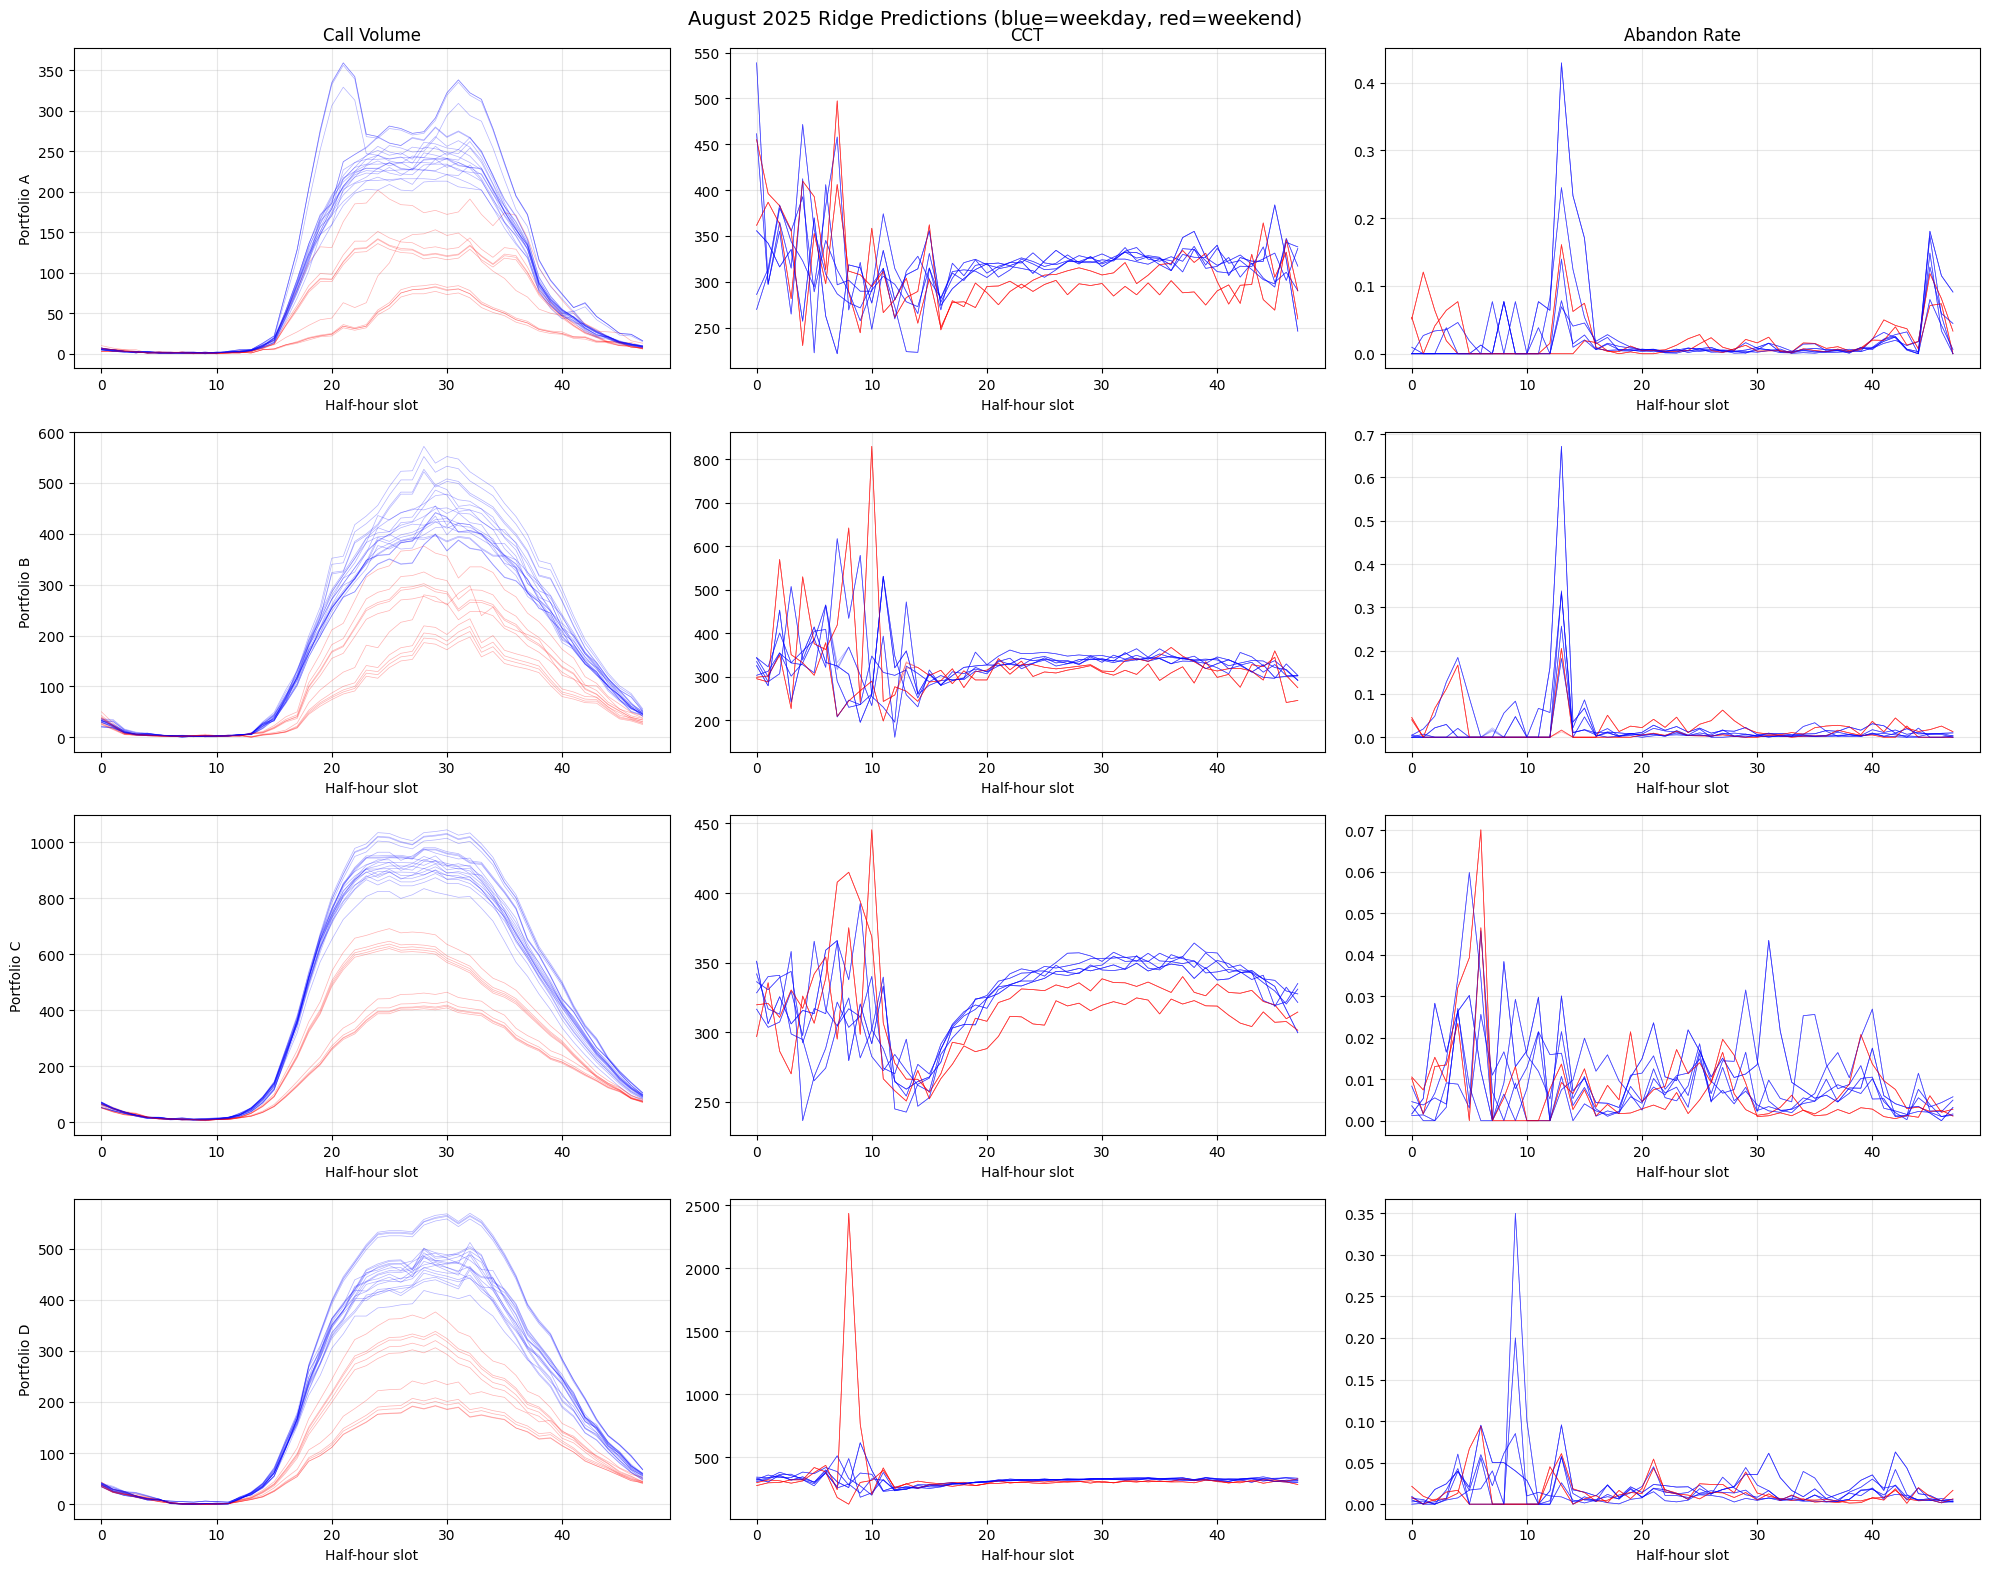

Done.


In [16]:
sub = pd.read_csv('submission_ridge.csv')

# Daily call volume totals: August predictions vs historical
print("DAILY CALL VOLUME TOTALS (Aug predictions vs historical):")
print(f"{'Portfolio':<10} {'Aug Daily Avg':>15} {'Hist Daily Avg':>15} {'Ratio':>8}")
print("-" * 55)
for p in PORTFOLIOS:
    aug_daily_cv = sub.groupby('Day')[f'Calls_Offered_{p}'].sum().mean()
    hist_daily_cv = daily_data[p]['Call Volume'].mean()
    ratio = aug_daily_cv / hist_daily_cv if hist_daily_cv > 0 else 0
    print(f"{p:<10} {aug_daily_cv:>15.0f} {hist_daily_cv:>15.0f} {ratio:>8.2f}")

print("\nWEEKDAY vs WEEKEND (Call Volume):")
for p in PORTFOLIOS:
    wd_days = [d for d in range(1, 32) if datetime(2025, 8, d).weekday() < 5]
    we_days = [d for d in range(1, 32) if datetime(2025, 8, d).weekday() >= 5]
    wd_avg = sub[sub['Day'].isin(wd_days)].groupby('Day')[f'Calls_Offered_{p}'].sum().mean()
    we_avg = sub[sub['Day'].isin(we_days)].groupby('Day')[f'Calls_Offered_{p}'].sum().mean()
    print(f"  {p}: Weekday={wd_avg:.0f}, Weekend={we_avg:.0f}, ratio={we_avg/wd_avg:.2f}")

print("\nCCT AVERAGES:")
for p in PORTFOLIOS:
    aug_cct = sub[f'CCT_{p}'].mean()
    hist_cct = daily_data[p]['CCT'].mean()
    print(f"  {p}: Aug={aug_cct:.1f}s, Historical={hist_cct:.1f}s")

print("\nABANDON RATE (daily weighted avg):")
for p in PORTFOLIOS:
    cv = sub[f'Calls_Offered_{p}']
    abd = sub[f'Abandoned_Rate_{p}']
    weighted = np.average(abd, weights=cv) if cv.sum() > 0 else 0
    hist_abd = daily_data[p]['Abandon Rate'].mean()
    print(f"  {p}: Aug={weighted:.4f}, Historical={hist_abd:.4f}")

print("\nABANDONED CALLS CONSISTENCY:")
for p in PORTFOLIOS:
    cv = sub[f'Calls_Offered_{p}']
    abd_r = sub[f'Abandoned_Rate_{p}']
    abd_c = sub[f'Abandoned_Calls_{p}']
    expected = np.round(abd_r * cv).astype(int)
    mismatch = (abd_c != expected).sum()
    print(f"  {p}: {mismatch} mismatches")

# Visualize August predictions
fig, axes = plt.subplots(4, 3, figsize=(20, 16))
metric_cols = [
    ('Calls_Offered', 'Call Volume'),
    ('CCT', 'CCT'),
    ('Abandoned_Rate', 'Abandon Rate'),
]

for j, p in enumerate(PORTFOLIOS):
    for i, (col_prefix, label) in enumerate(metric_cols):
        ax = axes[j, i]
        col = f'{col_prefix}_{p}'
        for day in range(1, 32):
            day_data = sub[sub['Day'] == day]
            is_weekend = datetime(2025, 8, day).weekday() >= 5
            color = 'red' if is_weekend else 'blue'
            ax.plot(range(len(day_data)), day_data[col].values, color=color, alpha=0.3, linewidth=0.5)
        ax.set_xlabel('Half-hour slot')
        if i == 0:
            ax.set_ylabel(f'Portfolio {p}')
        if j == 0:
            ax.set_title(label)
        ax.grid(True, alpha=0.3)

fig.suptitle('August 2025 Ridge Predictions (blue=weekday, red=weekend)', fontsize=14)
plt.tight_layout()
plt.show()
print("Done.")

## 8. Conclusions — handing off to `3_validation.ipynb`

### CV and CCT work

Jul 2025 holdout WMAPE:
- CV: A=17.1%, B=10.3%, C=7.4%, D=8.3%
- CCT: A=7.5%, B=9.3%, C=6.9%, D=6.8%

Decent for a linear model. The two-stage architecture (daily Ridge × DOW × half-hour profile) produces sane August predictions — daily totals within 88-101% of historical, weekend/weekday ratios 0.46-0.56, CCT within a few seconds of historical.

### Abandon Rate is broken

```
ABD WMAPE:  A=62.65%, B=64.07%, C=95.10%, D=86.27%
Best alpha: 1389.5
```

`alpha ≈ 1389` means RidgeCV decided the best thing it could do was shrink all coefficients to zero and predict the mean. WMAPE 63-95% confirms it. This isn't a hyperparameter problem. Squared loss plus L2 regularization just can't find signal on a target that's 50-70% exact zeros, bounded [0,1], and has std around 0.01.

One thing I noticed reviewing the submission code: for Abandon Rate, §6 uses the historical DOW × half-hour profile as the primary interval-level value and Stage-1 Ridge is only a fallback. So the broken Stage-1 never actually reaches the final numbers — the submission is basically a historical average for ABD. Fine as a baseline sanity check, not defensible as a final model.

### Questions for NB3

1. Where does Ridge CV/CCT fail? Residuals vs staffing, DOW, and holiday adjacency. If there's non-linear structure, that justifies moving to a tree model.
2. Are CV residuals heavy-tailed? EDA said CCT is but CV isn't — I need to check the residuals directly to decide whether robust/quantile loss is worth trying.
3. What do I do about Abandon Rate? Ridge clearly doesn't work. The fix probably isn't just "switch to XGBoost" — I'll likely need to change the target (model abandoned calls as a count, not a rate) and the loss (Poisson, not squared). NB3 should confirm the diagnosis.
